In [73]:
import pandas as pd
df1 = pd.read_csv('cars.csv')

In [75]:
df1

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0
...,...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,Hyundai,Hyundai Eon Era +,Eon,290000.0,38000.0,Petrol,Pune,14,6.0
1721,1721,2011,Bentley,Bentley Continental Flying Spur W12,Continental,7500000.0,36000.0,Petrol,Pune,44,10.0
1722,1722,2008,Mahindra-Renault,Mahindra-Renault Logan DLE 1.5 dci,Logan,185000.0,142522.0,Diesel,Pune,24,13.0
1723,1723,1990,Mahindra,Mahindra Jeep CJ 500 D,Jeep,325000.0,18581.0,Diesel,Pune,24,31.0


In [77]:
from sklearn import preprocessing

le=preprocessing.LabelEncoder()

df2=df1

df2.brand = le.fit_transform(df2.brand)
df2.full_model_name = le.fit_transform(df2.full_model_name)

df2.model_name = le.fit_transform(df2.model_name)

df2.fuel_type = le.fit_transform(df2.fuel_type)

df2.city = le.fit_transform(df2.city)

df2.brand = le.fit_transform(df2.brand)

df2

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,7,131,28,425000.0,9680.0,3,9,7,5.0
1,1,2012,23,570,129,325000.0,119120.0,1,9,11,9.0
2,2,2017,28,676,69,2650000.0,64593.0,1,14,1,4.0
3,3,2017,21,526,51,4195000.0,25000.0,1,9,2,4.0
4,4,2012,8,259,144,475000.0,23800.0,1,9,14,9.0
...,...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,8,221,59,290000.0,38000.0,3,13,14,6.0
1721,1721,2011,2,80,41,7500000.0,36000.0,3,13,44,10.0
1722,1722,2008,19,391,96,185000.0,142522.0,1,13,24,13.0
1723,1723,1990,18,347,89,325000.0,18581.0,1,13,24,31.0


In [79]:
print(df2.var())
print(df2.var().min())

df3=df2.drop('city',axis="columns")
df3

Id                         2.481125e+05
year                       1.028808e+01
brand                      8.461353e+01
full_model_name            4.718125e+04
model_name                 2.392481e+03
price                      2.794440e+12
distance_travelled(kms)    2.000374e+09
fuel_type                  1.017958e+00
city                       1.874791e+01
brand_rank                 1.677315e+02
car_age                    1.028808e+01
dtype: float64
1.0179582366589184


,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,brand_rank,car_age
0,0,2016,7,131,28,425000.0,9680.0,3,7,5.0
1,1,2012,23,570,129,325000.0,119120.0,1,11,9.0
2,2,2017,28,676,69,2650000.0,64593.0,1,1,4.0
3,3,2017,21,526,51,4195000.0,25000.0,1,2,4.0
4,4,2012,8,259,144,475000.0,23800.0,1,14,9.0
...,...,...,...,...,...,...,...,...,...,...
1720,1720,2015,8,221,59,290000.0,38000.0,3,14,6.0
1721,1721,2011,2,80,41,7500000.0,36000.0,3,44,10.0
1722,1722,2008,19,391,96,185000.0,142522.0,1,24,13.0
1723,1723,1990,18,347,89,325000.0,18581.0,1,24,31.0


In [81]:
X=df3.drop('price',axis="columns")
Y=df3[['price']]
print(type(Y))
print(type(X))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [85]:
from sklearn import linear_model

model=linear_model.LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [87]:
y_pred=model.predict(X_test)
print(type(y_pred))
print((type(y_test)))
y_pred_df=pd.DataFrame({'res':y_pred[:,0]})

from sklearn.metrics import mean_absolute_percentage_error
print(type(y_test))
print(type(y_pred))
print("MAPE ",mean_absolute_percentage_error(y_test,y_pred))


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>
MAPE  0.8813755006752688


In [89]:
from sklearn.metrics import mean_squared_error, r2_score
print("LINEAR REGRESSION",r2_score(y_test,y_pred))

LINEAR REGRESSION 0.2616198234446435


In [91]:

from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(n_estimators=500,max_features='log2', max_depth=50,random_state=42,max_samples=0.99)
rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('....mse......',mse)
print("RANDOM FOREST",r2)

/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


....mse...... 972722625803.7826
RANDOM FOREST 0.7102417042365274


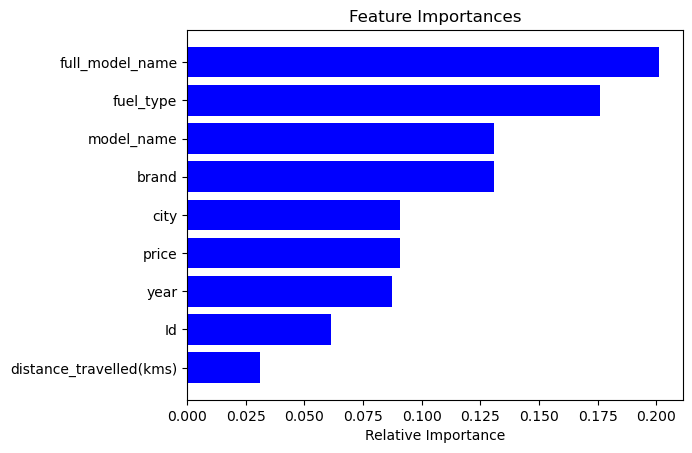

In [97]:
import matplotlib.pyplot as plt 
import numpy as np
features = df2.columns
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[-9:]  # top 10 features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

#### DECISION TREE MODEL

In [30]:
# Include the decistion Tree Library
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor()
#friedman_mse=0.59,poisson=65.85,squared_error=0.58,absolute_error=0.59
#max_depth=13 =>0.65

In [51]:
dt_model = DecisionTreeRegressor(criterion = 'poisson',max_depth = 13)
# fitting the model
dt_model.fit(X_train,y_train)

# predict the response
y_predict = dt_model.predict(X_test)

# to find the train score
dt_train_score = dt_model.score(X_train,y_train)
print('Decision Tree Model Training Score: ',dt_train_score)

# to find the test score
dt_test_score = dt_model.score(X_test,y_test)
print('Decision Tree Model Testing Score: ',dt_test_score)

# evaluate accuracy
dt_accuracy = mean_absolute_percentage_error(y_test, y_predict)

print('Decision Tree Model Accuracy Score:',dt_accuracy)


Decision Tree Model Training Score:  0.9975157254305644
Decision Tree Model Testing Score:  0.6667881935097333
Decision Tree Model Accuracy Score: 0.20970965835293653


In [53]:
# Best way to identify the Max Depth parameter
sample_depth = [2,5,7,9,10,13,15]
result = []
for i in sample_depth:
    dt_model_r = DecisionTreeRegressor(criterion = 'poisson',max_depth = i, random_state= 1)
    
    result.append(mean_absolute_percentage_error())

result

TypeError: missing a required argument: 'y_true'

In [55]:
from sklearn.ensemble import RandomForestRegressor

model_rf=RandomForestRegressor()
model_rf.fit(X_train,y_train)
y_predict=model_rf.predict(X_train)

print('training score',dt_model.score(X_train,y_train))
print('testing score',dt_model.score(X_test,y_test))

/home/admin1/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


training score 0.9975157254305644
testing score 0.6667881935097333


### DIMENSIONALITY REDUCTION

In [58]:
# checking the percentage of missing values in each variable
df2.isnull()
df2.isnull().sum()

df2.isnull().sum()/len(df2)*100

Id                         0.0
year                       0.0
brand                      0.0
full_model_name            0.0
model_name                 0.0
price                      0.0
distance_travelled(kms)    0.0
fuel_type                  0.0
city                       0.0
brand_rank                 0.0
car_age                    0.0
dtype: float64

In [60]:
#Let’s first impute the missing values in the Item_Weight column using the median value of the known Item_Weight observations. 
# For the Outlet_Size column, we will use the mode of the known Outlet_Size values to impute the missing values:

train['missingcol1'].fillna(train['missingcol1'].median(), inplace=True)
train['missingcol2'].fillna(train['missingcol2'].mode()[0], inplace=True)

NameError: name 'train' is not defined

In [62]:
#Let’s check whether all the missing values have been filled:

train.isnull().sum()/len(train)*100


#the variance of Item_Visibility is very less as compared to the other variables.

numeric = train[['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']]
var = numeric.var()
numeric = numeric.columns
variable = [ ]
for i in range(0,len(var)):
    if var[i]>=10:   #setting the threshold as 10%  ,
       variable.append(numeric[i])

NameError: name 'train' is not defined

In [64]:
#It gives us the list of variables that have a variance greater than 10.

variable

NameError: name 'variable' is not defined

In [66]:
import seaborn as sns
crm  = df2we don’t have any variables with a high correlation in our dataset. Generally, if the correlation between a pair of variables is greater than 0.5-0.6, we should seriously consider dropping one of those variables..corr()
sns.heatmap(crm, cmap="YlGnBu", annot=True)

SyntaxError: invalid character '’' (U+2019) (2778764492.py, line 2)

In [69]:
#we don’t have any variables with a high correlation in our dataset. Generally, if the correlation between a pair of variables is greater than 0.5-0.6, we should seriously consider dropping one of those variables.

In [71]:
from sklearn.ensemble import RandomForestRegressor



#model = RandomForestRegressor(random_state=1, max_depth=10)
#model.fit(X,y)

import matplotlib.pyplot as plt 

features = df2.columns
importances = rf.feature_importances_
indices = np.argsort(importances)[-9:]  # top 10 features
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

NameError: name 'rf' is not defined